In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 1. Parameters

In [2]:
params = {
    "R": 6.371e6,
    "sigma": 5.670374419e-8,

    "Ts": 5762.0,       # temperatura efektywna Słońca [K]
    "f": 2.16e-5,       # view factor Sun-Earth [-]
    "albedo": 0.35,     # albedo a [-]
    "gamma": 0.4,       # greenhouse factor c [-]

    "S0": 1380.0,       # [W/m^2]
}

article_values = {
    "candidate_1": {
        "x": 0.434,
        "lat_deg": 25.67,
        "TH": 293.9,
        "TL": 275.5,
        "q": 4.5e15,
        "D": 0.96,
        "Sgen": 3.9e14,
        "C32": 3.04e6,
    },
    "candidate_2": {
        "x": 0.800,
        "lat_deg": 53.13,
        "TH": 288.0,
        "TL": 265.5,
        "q": 6.2e15,
        "D": 1.06,
        "Sgen": 3.9e14,
        "C32": 3.04e6,
    },
}


## 2. Basic geometry and radiation

In [4]:
def planet_area(params):
    R = params["R"]
    return 4.0 * np.pi * R**2


def clip_x(x):
    return np.clip(x, 1e-12, 1.0 - 1e-12)


def latitude_from_x(x):
    """
    x = A_H / A = sin(theta)
    """
    x = clip_x(x)
    return np.degrees(np.arcsin(x))


def geometry(x):
    """
    Geometry terms from the article.

    x = A_H / A = sin(theta)

    geom_hot  = asin(x) + x*sqrt(1-x^2)
    geom_cold = pi/2 - asin(x) - x*sqrt(1-x^2)
    """
    x = clip_x(x)

    root_term = np.sqrt(1.0 - x**2)

    geom_hot = np.arcsin(x) + x * root_term
    geom_cold = 0.5 * np.pi - np.arcsin(x) - x * root_term

    return geom_hot, geom_cold


def B(params):
    """
    Article radiation parameter:

        B = Ts^4 * f/(2*pi) * (1-alpha)/(1-gamma)

    Units: K^4
    """
    Ts = params["Ts"]
    f = params["f"]
    alpha = params["albedo"]
    gamma = params["gamma"]

    return Ts**4 * (f / (2.0 * np.pi)) * ((1.0 - alpha) / (1.0 - gamma))


def radiation_denom(params):
    """
    denom = 4*pi*R^2*sigma*(1-gamma)

    Units: W/K^4
    """
    R = params["R"]
    sigma = params["sigma"]
    gamma = params["gamma"]

    return 4.0 * np.pi * R**2 * sigma * (1.0 - gamma)


print(f"B                   = {B(params):.6e} K^4")
print(f"radiation_denom     = {radiation_denom(params):.6e} W/K^4")
print(f"planet_area         = {planet_area(params):.6e} m^2")


B                   = 4.105150e+09 K^4
radiation_denom     = 1.735354e+07 W/K^4
planet_area         = 5.100645e+14 m^2


## 3. Article balances and Eq. (47)

In [6]:
def q_from_hot_balance(x, TH, params):
    """
    Hot-region balance, Eq. (9), solved for q:

        B*g_hot(x) - x*TH^4 - q/denom = 0

    Therefore:

        q = denom * [B*g_hot(x) - x*TH^4]
    """
    geom_hot, _ = geometry(x)
    return radiation_denom(params) * (B(params) * geom_hot - x * TH**4)


def q_from_cold_balance(x, TL, params):
    """
    Cold-region balance, Eq. (10), solved for q:

        B*g_cold(x) - (1-x)*TL^4 + q/denom = 0

    Therefore:

        q = denom * [(1-x)*TL^4 - B*g_cold(x)]
    """
    _, geom_cold = geometry(x)
    return radiation_denom(params) * ((1.0 - x) * TL**4 - B(params) * geom_cold)


def TL_from_eq47(x, TH, params):
    """
    Combined radiation balance, Eq. (47):

        x*TH^4 + (1-x)*TL^4 = (pi/2)*B

    Given x and TH, compute TL.
    """
    x = clip_x(x)

    val = (0.5 * np.pi * B(params) - x * TH**4) / (1.0 - x)

    if val <= 0.0:
        return np.nan

    return val**0.25


def TH_from_eq47(x, TL, params):
    """
    Combined radiation balance, Eq. (47):

        x*TH^4 + (1-x)*TL^4 = (pi/2)*B

    Given x and TL, compute TH.
    """
    x = clip_x(x)

    val = (0.5 * np.pi * B(params) - (1.0 - x) * TL**4) / x

    if val <= 0.0:
        return np.nan

    return val**0.25


def balance_error(x, TH, TL, params):
    return q_from_hot_balance(x, TH, params) - q_from_cold_balance(x, TL, params)


## 4. Heat transport coefficient and entropy production

In [ ]:
def C32_from_article_eq33(x, TH, TL, params):
    """
    Article-normalized C_3/2 from Eq. (33):

        C32 * (TH - TL)^(3/2) = B*g_hot(x) - x*TH^4

    This code does NOT calibrate C32 from the table.
    It calculates the effective C32 implied by the optimized point.
    """
    dT = TH - TL

    if dT <= 0.0:
        return np.nan

    q = q_from_hot_balance(x, TH, params)
    q_normalized = q / radiation_denom(params)

    if q_normalized <= 0.0:
        return np.nan

    return q_normalized / dT**1.5


def heat_transport_from_C32(x, TH, TL, params):
    """
    Diagnostic reconstruction:

        q = denom * C32 * (TH - TL)^(3/2)

    Here C32 is computed from Eq. (33), so this should reproduce q.
    """
    C32 = C32_from_article_eq33(x, TH, TL, params)

    if not np.isfinite(C32):
        return np.nan

    return radiation_denom(params) * C32 * (TH - TL)**1.5


def entropy_production_transport(q, TH, TL):
    """
    Transport-only entropy production:

        Sgen_transport = q * (1/TL - 1/TH)
    """
    if TH <= 0.0 or TL <= 0.0:
        return np.nan

    return q * (1.0 / TL - 1.0 / TH)


def entropy_production_total_article(x, TH, TL, q, params):
    """
    Total entropy production from Eq. (51):

        Sgen = S0*(1-alpha)*pi*R^2 * [x/TH + (1-x)/TL - 1/Ts]
               + q*(1/TL - 1/TH)
    """
    R = params["R"]
    Ts = params["Ts"]
    alpha = params["albedo"]
    S0 = params["S0"]

    radiative_part = (
        S0 * (1.0 - alpha) * np.pi * R**2
        * (x / TH + (1.0 - x) / TL - 1.0 / Ts)
    )

    transport_part = entropy_production_transport(q, TH, TL)

    return radiative_part + transport_part


def mean_temperature(x, TH, TL):
    return x * TH + (1.0 - x) * TL


def horizontal_conductance_D(q, TH, TL, params):
    """
    Diagnostic conductance:

        q = D * A * (TH - TL)

    where A = 4*pi*R^2.
    """
    dT = TH - TL

    if dT <= 0.0:
        return np.nan

    return q / (planet_area(params) * dT)


## 5. Article-style maxima for fixed `TH` and fixed `TL`

Z pochodnej członów geometrycznych:

\[
\frac{d}{dx}\left[\arcsin x+x\sqrt{1-x^2}\right] = 2\sqrt{1-x^2}
\]

Dla obu rodzin maksimum `q(x)` spełnia:

\[
2B\sqrt{1-x^2}=T^4
\]

czyli:

\[
x=\sqrt{1-\left(\frac{T^4}{2B}\right)^2}
\]


In [8]:
# ============================================================
# 5. ARTICLE-STYLE Q MAXIMA FOR FIXED TH AND FIXED TL
# ============================================================

def x_qmax_for_fixed_temperature(T, params):
    """
    Analytical q-maximum condition for both fixed-TH and fixed-TL families:

        2*B*sqrt(1-x^2) = T^4
    """
    ratio = T**4 / (2.0 * B(params))

    if ratio <= 0.0 or ratio >= 1.0:
        return np.nan

    return np.sqrt(1.0 - ratio**2)


def build_row(x, TH, TL, q, family, params):
    """
    Collects all diagnostics in the same style as the original code.
    """
    return {
        "family": family,
        "x": x,
        "lat_deg": latitude_from_x(x),
        "TH": TH,
        "TL": TL,
        "Tmean": mean_temperature(x, TH, TL),
        "dT": TH - TL,
        "q": q,
        "D": horizontal_conductance_D(q, TH, TL, params),
        "Sgen_transport": entropy_production_transport(q, TH, TL),
        "Sgen_total": entropy_production_total_article(x, TH, TL, q, params),
        "C32_effective": C32_from_article_eq33(x, TH, TL, params),
        "q_from_hot": q_from_hot_balance(x, TH, params),
        "q_from_cold": q_from_cold_balance(x, TL, params),
        "balance_error": balance_error(x, TH, TL, params),
    }


def given_TH_article(x, TH, params):
    """
    Given x and TH, article-style version:

    1. Compute q from the hot-region balance.
    2. Compute TL from Eq. (47), not from transport law.
    3. Check physical validity.
    """
    TL = TL_from_eq47(x, TH, params)

    if not np.isfinite(TL) or TL <= 0.0 or TL >= TH:
        return None

    q = q_from_hot_balance(x, TH, params)

    if q <= 0.0:
        return None

    return build_row(x, TH, TL, q, "fixed_TH", params)


def given_TL_article(x, TL, params):
    """
    Given x and TL, article-style version:

    1. Compute q from the cold-region balance.
    2. Compute TH from Eq. (47), not from transport law.
    3. Check physical validity.
    """
    TH = TH_from_eq47(x, TL, params)

    if not np.isfinite(TH) or TH <= TL:
        return None

    q = q_from_cold_balance(x, TL, params)

    if q <= 0.0:
        return None

    return build_row(x, TH, TL, q, "fixed_TL", params)


def best_for_given_TH_article(TH, params):
    """
    For fixed TH, find x that maximizes q.

    The article condition gives x analytically, so no numerical optimizer is needed.
    """
    x = x_qmax_for_fixed_temperature(TH, params)

    if not np.isfinite(x):
        return None

    return given_TH_article(x, TH, params)


def best_for_given_TL_article(TL, params):
    """
    For fixed TL, find x that maximizes q.

    The article condition gives x analytically, so no numerical optimizer is needed.
    """
    x = x_qmax_for_fixed_temperature(TL, params)

    if not np.isfinite(x):
        return None

    return given_TL_article(x, TL, params)


## 6. Scan families and select candidates

In [9]:
def scan_TH_family_article(params, TH_min=285.0, TH_max=300.0, n_TH=800):
    TH_values = np.linspace(TH_min, TH_max, n_TH)
    rows = []

    for TH in TH_values:
        out = best_for_given_TH_article(TH, params)

        if out is not None:
            rows.append(out)

    return pd.DataFrame(rows)


def scan_TL_family_article(params, TL_min=250.0, TL_max=280.0, n_TL=800):
    TL_values = np.linspace(TL_min, TL_max, n_TL)
    rows = []

    for TL in TL_values:
        out = best_for_given_TL_article(TL, params)

        if out is not None:
            rows.append(out)

    return pd.DataFrame(rows)


def find_case_1_article(params, TH_min=285.0, TH_max=300.0):
    """
    Candidate 1 / Case I from the article:

        q is maximum at fixed TH,
        then TL is minimum along that family.
    """

    def objective(TH):
        out = best_for_given_TH_article(TH, params)

        if out is None:
            return 1e100

        return out["TL"]

    sol = minimize_scalar(
        objective,
        bounds=(TH_min, TH_max),
        method="bounded",
        options={"xatol": 1e-12},
    )

    out = best_for_given_TH_article(sol.x, params)
    out["candidate"] = "candidate_1"
    out["selection_rule"] = "min TL along q-maxima at fixed TH"
    out["optimizer_success"] = sol.success

    return out


def find_case_2_article(params, TL_min=250.0, TL_max=280.0):
    """
    Candidate 2 / Case II from the article:

        q is maximum at fixed TL,
        then TH is maximum along that family.
    """

    def objective(TL):
        out = best_for_given_TL_article(TL, params)

        if out is None:
            return 1e100

        return -out["TH"]

    sol = minimize_scalar(
        objective,
        bounds=(TL_min, TL_max),
        method="bounded",
        options={"xatol": 1e-12},
    )

    out = best_for_given_TL_article(sol.x, params)
    out["candidate"] = "candidate_2"
    out["selection_rule"] = "max TH along q-maxima at fixed TL"
    out["optimizer_success"] = sol.success

    return out


## 7. Comparison with article

In [10]:
def compare_with_article(results):
    """
    Compare model candidates with article values.
    """
    c1 = results["candidate_1"]
    c2 = results["candidate_2"]

    model = {
        "candidate_1": c1,
        "candidate_2": c2,
    }

    rows = []

    for cand_name in ["candidate_1", "candidate_2"]:
        for var_model, var_article in [
            ("x", "x"),
            ("lat_deg", "lat_deg"),
            ("TH", "TH"),
            ("TL", "TL"),
            ("Tmean", None),
            ("q", "q"),
            ("D", "D"),
            ("Sgen_total", "Sgen"),
            ("C32_effective", "C32"),
        ]:
            model_value = model[cand_name][var_model]

            if var_article is None:
                article_value = (
                    article_values[cand_name]["x"] * article_values[cand_name]["TH"]
                    + (1.0 - article_values[cand_name]["x"]) * article_values[cand_name]["TL"]
                )
            else:
                article_value = article_values[cand_name][var_article]

            rows.append({
                "candidate": cand_name,
                "variable": var_model,
                "model": model_value,
                "article": article_value,
                "error": model_value - article_value,
                "relative_error_%": 100.0 * (model_value - article_value) / article_value,
            })

    return pd.DataFrame(rows)


def print_result(name, row):
    print()
    print(name)
    print("=" * len(name))
    print(f"x                    = {row['x']:.5f}")
    print(f"latitude             = {row['lat_deg']:.3f} deg")
    print(f"TH                   = {row['TH']:.3f} K")
    print(f"TL                   = {row['TL']:.3f} K")
    print(f"Tmean                = {row['Tmean']:.3f} K")
    print(f"dT                   = {row['dT']:.3f} K")
    print(f"q                    = {row['q']:.6e} W")
    print(f"D                    = {row['D']:.6e} W/m^2/K")
    print(f"Sgen transport       = {row['Sgen_transport']:.6e} W/K")
    print(f"Sgen total Eq. 51    = {row['Sgen_total']:.6e} W/K")
    print(f"C32 effective        = {row['C32_effective']:.6e} K^(5/2)")
    print(f"q hot                = {row['q_from_hot']:.6e} W")
    print(f"q cold               = {row['q_from_cold']:.6e} W")
    print(f"balance error        = {row['balance_error']:.6e} W")
    print(f"selection rule       = {row['selection_rule']}")


def print_comparison_table(df, title):
    print()
    print(title)
    print("=" * len(title))

    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", 160,
        "display.float_format", "{:.6g}".format,
    ):
        print(df)


## 8. Plots

In [11]:
def q_curve_fixed_TH_article(TH, params, x_min=0.02, x_max=0.98, n=500):
    xs = np.linspace(x_min, x_max, n)
    rows = []

    for x in xs:
        out = given_TH_article(x, TH, params)

        if out is not None:
            rows.append(out)

    return pd.DataFrame(rows)


def q_curve_fixed_TL_article(TL, params, x_min=0.02, x_max=0.98, n=500):
    xs = np.linspace(x_min, x_max, n)
    rows = []

    for x in xs:
        out = given_TL_article(x, TL, params)

        if out is not None:
            rows.append(out)

    return pd.DataFrame(rows)


def plot_fig7_like_TH_curves(params, candidate_1, offsets=(-0.5, 0.0, 0.5), x_half_width=0.1, n=500):
    """
    Fig. 7-like plot:
    q(x) at constant TH, centered on candidate 1.
    """
    TH_center = candidate_1["TH"]
    x_center = candidate_1["x"]

    TH_values = tuple(TH_center + d for d in offsets)

    x_min = max(0.02, x_center - x_half_width)
    x_max = min(0.98, x_center + x_half_width)

    plt.figure(figsize=(7, 5))

    for TH in TH_values:
        df = q_curve_fixed_TH_article(TH, params, x_min=x_min, x_max=x_max, n=n)

        if df.empty:
            continue

        plt.plot(df["x"], df["q"] / 1e15, label=f"$T_H$={TH:.2f} K")

        peak = best_for_given_TH_article(TH, params)

        if peak is not None and x_min <= peak["x"] <= x_max:
            plt.plot(
                peak["x"],
                peak["q"] / 1e15,
                marker="v",
                markersize=8,
            )

            plt.text(
                peak["x"] + 0.002,
                peak["q"] / 1e15 + 0.005,
                f"$T_L$={peak['TL']:.2f} K",
                fontsize=9,
            )

    plt.axvline(candidate_1["x"], linestyle="--", linewidth=1)

    plt.xlabel("x")
    plt.ylabel(r"$q$ $(\times 10^{15}\ \mathrm{W})$")
    plt.title(r"Fig. 7-like: $q(x)$ at constant $T_H$")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_fig8_like_TL_curves(params, candidate_2, offsets=(-0.5, 0.0, 0.5), x_half_width=0.1, n=500):
    """
    Fig. 8-like plot:
    q(x) at constant TL, centered on candidate 2.
    """
    TL_center = candidate_2["TL"]
    x_center = candidate_2["x"]

    TL_values = tuple(TL_center + d for d in offsets)

    x_min = max(0.02, x_center - x_half_width)
    x_max = min(0.98, x_center + x_half_width)

    plt.figure(figsize=(7, 5))

    for TL in TL_values:
        df = q_curve_fixed_TL_article(TL, params, x_min=x_min, x_max=x_max, n=n)

        if df.empty:
            continue

        plt.plot(df["x"], df["q"] / 1e15, label=f"$T_L$={TL:.2f} K")

        peak = best_for_given_TL_article(TL, params)

        if peak is not None and x_min <= peak["x"] <= x_max:
            plt.plot(
                peak["x"],
                peak["q"] / 1e15,
                marker="v",
                markersize=8,
            )

            plt.text(
                peak["x"] + 0.002,
                peak["q"] / 1e15 + 0.015,
                f"$T_H$={peak['TH']:.2f} K",
                fontsize=9,
            )

    plt.axvline(candidate_2["x"], linestyle="--", linewidth=1)

    plt.xlabel("x")
    plt.ylabel(r"$q$ $(\times 10^{15}\ \mathrm{W})$")
    plt.title(r"Fig. 8-like: $q(x)$ at constant $T_L$")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_family_diagnostics(df_TH, df_TL, candidate_1, candidate_2):
    plt.figure(figsize=(7, 5))
    plt.plot(df_TH["lat_deg"], df_TH["q"] / 1e15, label="fixed TH branch")
    plt.plot(df_TL["lat_deg"], df_TL["q"] / 1e15, label="fixed TL branch")
    plt.axvline(candidate_1["lat_deg"], linestyle="--", linewidth=1)
    plt.axvline(candidate_2["lat_deg"], linestyle="--", linewidth=1)
    plt.xlabel("Boundary latitude [deg]")
    plt.ylabel(r"$q$ $(\times 10^{15}\ \mathrm{W})$")
    plt.title("Heat transport along article-style q-maxima")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(df_TH["lat_deg"], df_TH["TH"], label="TH, fixed TH branch")
    plt.plot(df_TH["lat_deg"], df_TH["TL"], label="TL, fixed TH branch")
    plt.plot(df_TL["lat_deg"], df_TL["TH"], label="TH, fixed TL branch")
    plt.plot(df_TL["lat_deg"], df_TL["TL"], label="TL, fixed TL branch")
    plt.axvline(candidate_1["lat_deg"], linestyle="--", linewidth=1)
    plt.axvline(candidate_2["lat_deg"], linestyle="--", linewidth=1)
    plt.xlabel("Boundary latitude [deg]")
    plt.ylabel("Temperature [K]")
    plt.title("Temperatures along article-style q-maxima")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(df_TH["lat_deg"], df_TH["Sgen_total"] / 1e14, label="fixed TH branch")
    plt.plot(df_TL["lat_deg"], df_TL["Sgen_total"] / 1e14, label="fixed TL branch")
    plt.axvline(candidate_1["lat_deg"], linestyle="--", linewidth=1)
    plt.axvline(candidate_2["lat_deg"], linestyle="--", linewidth=1)
    plt.xlabel("Boundary latitude [deg]")
    plt.ylabel(r"$S_{gen}$ $(\times 10^{14}\ \mathrm{W/K})$")
    plt.title("Total entropy production, Eq. (51)")
    plt.grid(True)
    plt.legend()
    plt.show()


## 9. Main experiment

In [12]:
def run_experiment(params, make_plots=True):
    print("Model parameters")
    print("================")
    for k, v in params.items():
        print(f"{k:14s} = {v}")

    print()
    print(f"B                           = {B(params):.6e} K^4")
    print(f"Radiation denom             = {radiation_denom(params):.6e} W/K^4")
    print(f"Planet surface area         = {planet_area(params):.6e} m^2")
    print()

    # Article-style families
    df_TH = scan_TH_family_article(params)
    df_TL = scan_TL_family_article(params)

    if df_TH.empty:
        raise RuntimeError("df_TH is empty. Check TH range or model parameters.")

    if df_TL.empty:
        raise RuntimeError("df_TL is empty. Check TL range or model parameters.")

    # Article-style candidates
    candidate_1 = find_case_1_article(params)
    candidate_2 = find_case_2_article(params)

    print_result(
        "Candidate 1 ARTICLE-STYLE: minimum TL along fixed-TH q-maxima",
        candidate_1,
    )

    print_result(
        "Candidate 2 ARTICLE-STYLE: maximum TH along fixed-TL q-maxima",
        candidate_2,
    )

    results = {
        "df_TH": df_TH,
        "df_TL": df_TL,
        "candidate_1": candidate_1,
        "candidate_2": candidate_2,
    }

    comparison = compare_with_article(results)
    results["comparison"] = comparison

    print_comparison_table(
        comparison,
        "Comparison with article",
    )

    if make_plots:
        plot_fig7_like_TH_curves(
            params,
            candidate_1=candidate_1,
            offsets=(-0.3, 0.0, 0.3),
            x_half_width=0.1,
            n=600,
        )

        plot_fig8_like_TL_curves(
            params,
            candidate_2=candidate_2,
            offsets=(-2.5, 0.0, 2.5),
            x_half_width=0.07,
            n=600,
        )

        plot_family_diagnostics(
            df_TH=df_TH,
            df_TL=df_TL,
            candidate_1=candidate_1,
            candidate_2=candidate_2,
        )

    return results


## 10. Run

Model parameters
R              = 6371000.0
sigma          = 5.670374419e-08
Ts             = 5762.0
f              = 2.16e-05
albedo         = 0.35
gamma          = 0.4
S0             = 1380.0

B                           = 4.105150e+09 K^4
Radiation denom             = 1.735354e+07 W/K^4
Planet surface area         = 5.100645e+14 m^2


Candidate 1 ARTICLE-STYLE: minimum TL along fixed-TH q-maxima
x                    = 0.43079
latitude             = 25.518 deg
TH                   = 293.390 K
TL                   = 275.022 K
Tmean                = 282.935 K
dT                   = 18.368 K
q                    = 4.032227e+15 W
D                    = 4.303916e-01 W/m^2/K
Sgen transport       = 9.178824e+11 W/K
Sgen total Eq. 51    = 3.857504e+14 W/K
C32 effective        = 2.951704e+06 K^(5/2)
q hot                = 4.032227e+15 W
q cold               = 4.032227e+15 W
balance error        = 8.500000e+00 W
selection rule       = min TL along q-maxima at fixed TH

Candidate 2 ARTICLE-STYL

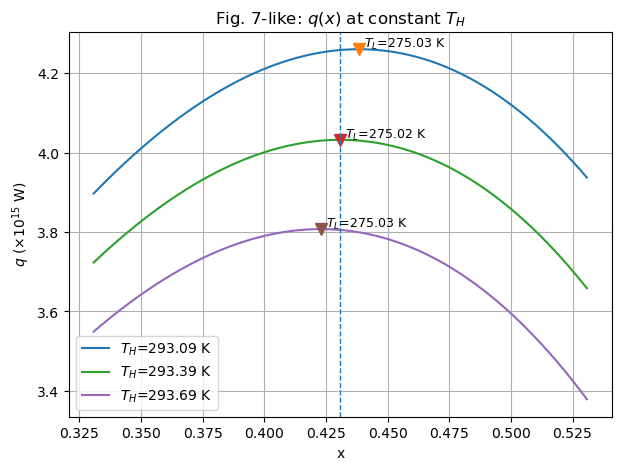

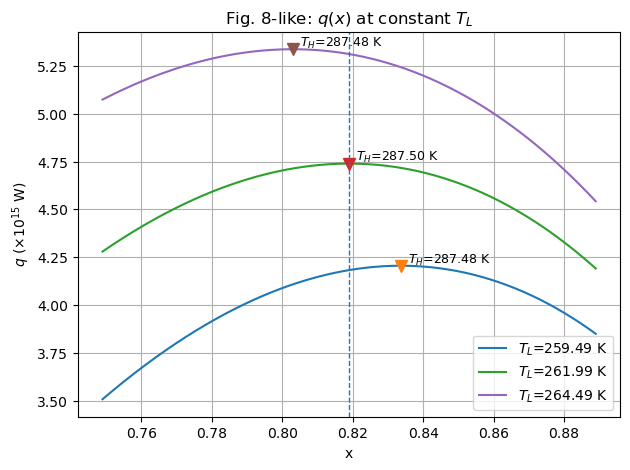

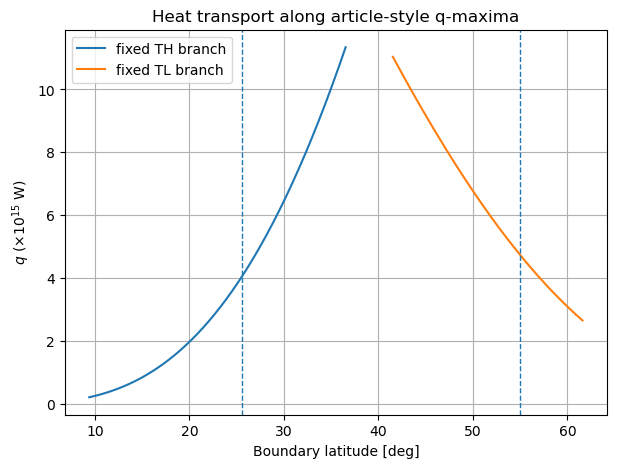

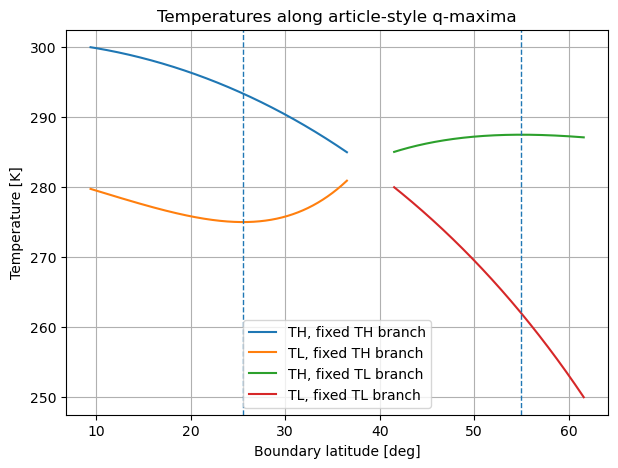

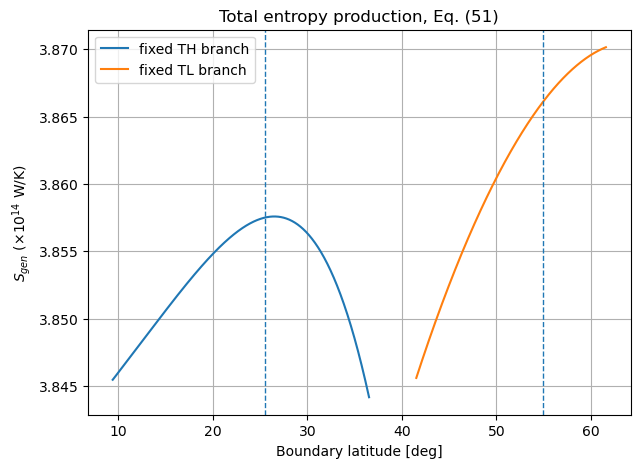

In [13]:
results = run_experiment(params, make_plots=True)

## 11. Tables as DataFrames

In [14]:
# Main candidates as a compact table

candidates_df = pd.DataFrame([
    results["candidate_1"],
    results["candidate_2"],
])

cols = [
    "candidate",
    "selection_rule",
    "x",
    "lat_deg",
    "TH",
    "TL",
    "Tmean",
    "dT",
    "q",
    "D",
    "Sgen_transport",
    "Sgen_total",
    "C32_effective",
    "balance_error",
]

candidates_df[cols]


,candidate,selection_rule,x,lat_deg,TH,TL,Tmean,dT,q,D,Sgen_transport,Sgen_total,C32_effective,balance_error
0,candidate_1,min TL along q-maxima at fixed TH,0.430792,25.517843,293.390251,275.022498,282.935182,18.367752,4.032227e+15,0.430392,9.178824e+11,3.857504e+14,2.951704e+06,8.5
1,candidate_2,max TH along q-maxima at fixed TL,0.818989,54.983736,287.502653,261.988107,282.884245,25.514546,4.739199e+15,0.364160,1.605349e+12,3.866142e+14,2.119020e+06,-17.0


In [15]:
# Comparison table

results["comparison"]


,candidate,variable,model,article,error,relative_error_%
0,candidate_1,x,4.307922e-01,4.340000e-01,-3.207846e-03,-0.739135
1,candidate_1,lat_deg,2.551784e+01,2.567000e+01,-1.521572e-01,-0.592743
2,candidate_1,TH,2.933903e+02,2.939000e+02,-5.097491e-01,-0.173443
3,candidate_1,TL,2.750225e+02,2.755000e+02,-4.775015e-01,-0.173322
4,candidate_1,Tmean,2.829352e+02,2.834856e+02,-5.504179e-01,-0.194161
5,candidate_1,q,4.032227e+15,4.500000e+15,-4.677735e+14,-10.394966
6,candidate_1,D,4.303916e-01,9.600000e-01,-5.296084e-01,-55.167537
7,candidate_1,Sgen_total,3.857504e+14,3.900000e+14,-4.249597e+12,-1.089640
8,candidate_1,C32_effective,2.951704e+06,3.040000e+06,-8.829578e+04,-2.904467
9,candidate_2,x,8.189892e-01,8.000000e-01,1.898920e-02,2.373649
